In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

response = requests.get("https://www.iari.res.in/bms/daily-weather/")
soup = BeautifulSoup(response.text, 'html.parser')

# Locate the table containing "Monthly and Annual Rainfall"
table = soup.find('strong', string="MONTHLY AND ANNUAL RAINFALL").find_next('table')

rows = []
for tr in table.find_all('tr')[1:]:  # Skip header
    cols = [td.get_text(strip=True) for td in tr.find_all(['td', 'th'])]
    rows.append(cols)

# Create DataFrame
header = [th.get_text(strip=True) for th in table.find_all('th')]
df = pd.DataFrame(rows, columns=header)
df = df.set_index('Month/Year')
print(df)

AttributeError: 'NoneType' object has no attribute 'find_next'

In [4]:
from bs4 import BeautifulSoup
import requests

url = "https://www.iari.res.in/bms/daily-weather/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Find and print all <strong> tags
for tag in soup.find_all('strong'):
    print(tag.text)

 *Rainfall recorded
(up to 04th September, 2025 Morning 8:30 AM)   


In [5]:
import pandas as pd

url = "https://www.iari.res.in/bms/daily-weather/"
tables = pd.read_html(url)

print(f"Total tables found: {len(tables)}")

for i, table in enumerate(tables):
    print(f"\nTable {i} preview:")
    print(table.head())

Total tables found: 4

Table 0 preview:
    0                                                  1   2
0 NaN  भा.कृ.अ.प. - भारतीय कृषि अनुसंधान संस्थान | IC... NaN

Table 1 preview:
         Date  Max Temp (℃)  Min Temp (℃)  Rainfall (mm)  Wind Speed (km/h)  \
0  27/08/2025          31.3          26.0            0.2                4.3   
1  28/08/2025          30.3          25.5           18.0                1.9   
2  29/08/2025          34.3          27.1            0.2                4.7   
3  30/08/2025          31.0          25.4           12.3                5.8   
4  31/08/2025          33.3          26.4            0.5                4.8   

  Wind Direction-I Wind Direction-II  Weather Condition-I (Code 0-9)  \
0                C                 S                               2   
1                C                SE                               4   
2                C                 E                               5   
3               SE                SE                     

In [7]:
rainfall_df = tables[2]
rainfall_df.head()

,Month/Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total
0,2020,47.7,2.0,174.6,8.8,37.4,59.9,270.9,334.6,9.8,0.0,3.2,0.0,948.9
1,2021,56.3,7.0,2.0,5.2,214.6,50.1,497.1,257.4,528.6,127.7,0.0,9.6,1755.6
2,2022,141.9,30.0,0.0,0.0,74.8,22.8,325.6,168.2,191.4,134.9,0.0,0.0,1089.6
3,2023,33.4,0.0,105.0,10.9,118.3,234.8,366.0,181.2,85.7,4.0,12.4,0.0,1151.7
4,2024,0.0,28.8,11.2,15.0,0.0,117.0,349.8,370.4,163.3,0.0,0.0,49.7*,1105.2


In [19]:
import numpy as np
data_2025 = {
    'Month/Year': 2025,
    'Jan': 11.3,
    'Feb': 1.2,
    'Mar': 2.6,
    'Apr': 0.4,
    'May': 129.7,
    'Jun': 113.6,
    'Jul': 326.0,
    'Aug': 394.5,
    'Sep': 72.5,
    'Oct': np.nan,
    'Nov': np.nan,
    'Dec': np.nan,
    'Total': np.nan,  # or sum of months
}

In [23]:
df_2025 = pd.DataFrame([data_2025])
df_2025

,Month/Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total
0,2025,11.3,1.2,2.6,0.4,129.7,113.6,326.0,394.5,72.5,NaN,NaN,NaN,NaN


In [26]:
df_updated = pd.concat([rainfall_df, df_2025], ignore_index= True)

In [28]:
df_updated.tail()

,Month/Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total
2,2022,141.9,30.0,0.0,0.0,74.8,22.8,325.6,168.2,191.4,134.9,0.0,0.0,1089.6
3,2023,33.4,0.0,105.0,10.9,118.3,234.8,366.0,181.2,85.7,4.0,12.4,0.0,1151.7
4,2024,0.0,28.8,11.2,15.0,0.0,117.0,349.8,370.4,163.3,0.0,0.0,49.7*,1105.2
5,2025,11.3,1.2,2.6,0.4,129.7,113.6,326.0*,394.5,72.5,NaN,NaN,NaN,1051.8
6,2025,11.3,1.2,2.6,0.4,129.7,113.6,326.0,394.5,72.5,NaN,NaN,NaN,NaN


In [30]:
import pandas as pd

# Assuming `df` is your rainfall DataFrame extracted from the web

# 1. Drop unnecessary columns like "Annual Total"
df = df_updated.drop(columns=["Annual Total"], errors='ignore')

# 2. Rename 'Month/Year' column to 'Year' for clarity
df = df_updated.rename(columns={"Month/Year": "Year"})

# 3. Convert wide to long format using melt
df_long = pd.melt(df, 
                  id_vars=["Year"], 
                  var_name="Month", 
                  value_name="Rainfall_mm")

# 4. Clean up data types
df_long["Rainfall_mm"] = pd.to_numeric(df_long["Rainfall_mm"], errors="coerce")
df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce").astype("Int64")

In [31]:
df_long.head()

,Year,Month,Rainfall_mm
0,2020,Jan,47.7
1,2021,Jan,56.3
2,2022,Jan,141.9
3,2023,Jan,33.4
4,2024,Jan,0.0


In [32]:
threshold = df_long["Rainfall_mm"].quantile(0.9)

In [33]:
df_long["Flood_Prone"] = df_long["Rainfall_mm"] > threshold

In [34]:
known_floods = [("2023", "Jul"), ("2021", "Aug"), ("2020", "Sep")]

# Add a flood label
df_long["Flood_Prone"] = df_long.apply(
    lambda row: (str(row["Year"]), row["Month"]) in known_floods,
    axis=1
)

Month
Total    1183.800000
Jul       355.900000
Aug       300.114286
Sep       160.542857
Jun       101.685714
May       100.642857
Oct        53.320000
Jan        43.128571
Mar        42.571429
Feb        10.028571
Apr         5.814286
Nov         3.120000
Dec         2.400000
Name: Rainfall_mm, dtype: float64


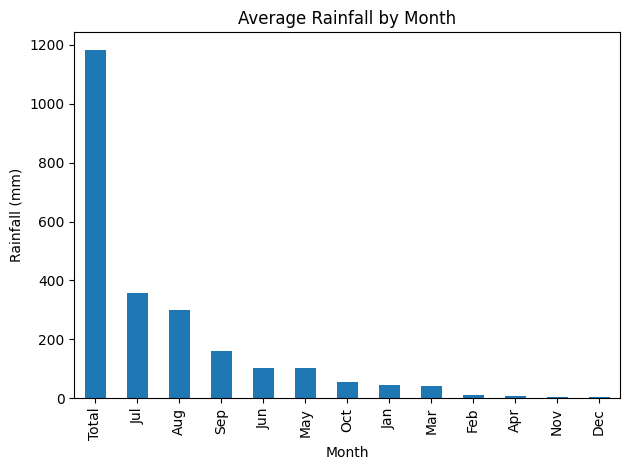

In [35]:
import matplotlib.pyplot as plt

# Average rainfall by month
monthly_avg = df_long.groupby("Month")["Rainfall_mm"].mean().sort_values(ascending=False)
print(monthly_avg)

# Plot
monthly_avg.plot(kind="bar", title="Average Rainfall by Month", ylabel="Rainfall (mm)", xlabel="Month")
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Total Rainfall Per Year'}, xlabel='Year', ylabel='Rainfall_mm'>

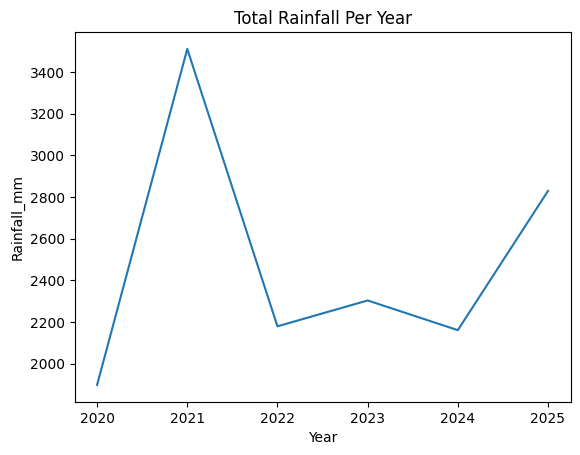

In [43]:
df_long.groupby("Year")["Rainfall_mm"].sum().plot(kind="line", title="Total Rainfall Per Year",ylabel= 'Rainfall_mm')

In [44]:
monthly_avg = df_long.groupby("Month")["Rainfall_mm"].mean()
df_long["Anomaly"] = df_long.apply(lambda x: x["Rainfall_mm"] - monthly_avg[x["Month"]], axis=1)

In [45]:
df_long.head()

,Year,Month,Rainfall_mm,Flood_Prone,Anomaly
0,2020,Jan,47.7,False,4.571429
1,2021,Jan,56.3,False,13.171429
2,2022,Jan,141.9,False,98.771429
3,2023,Jan,33.4,False,-9.728571
4,2024,Jan,0.0,False,-43.128571


C:\Users\vedant\AppData\Local\Temp\ipykernel_5180\2589715393.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20c')(range(len(seasonal_percent)))  # 12 unique colors


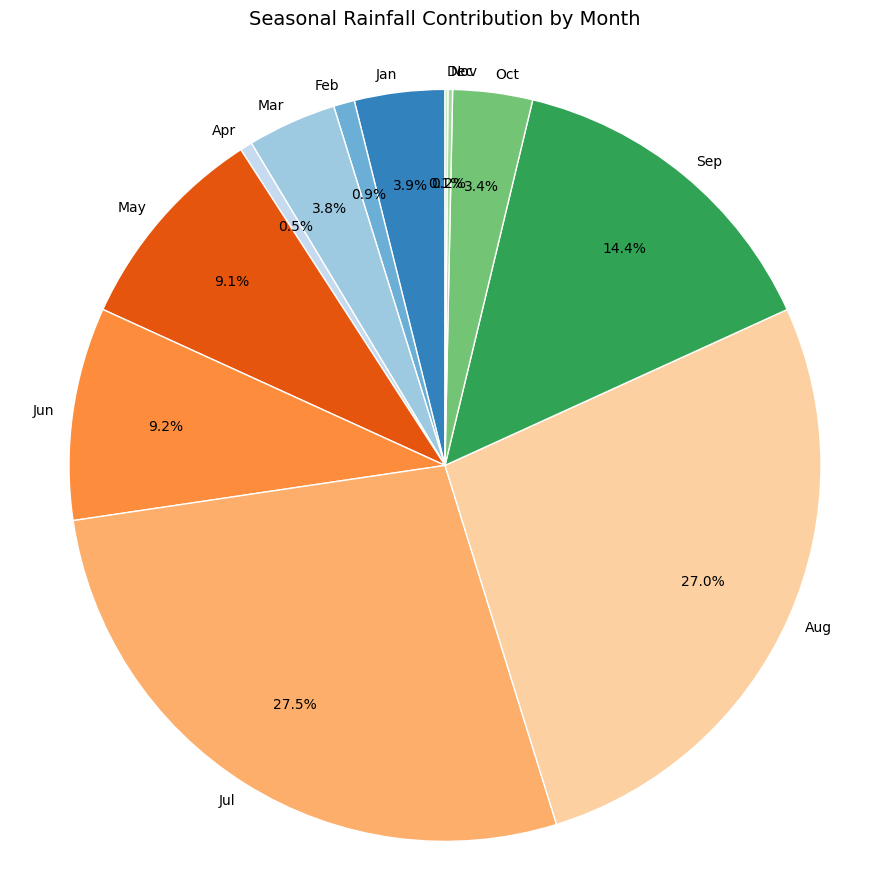

In [50]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Step 1: Group and calculate percentage
seasonal_totals = df_long.groupby("Month")["Rainfall_mm"].sum()
seasonal_percent = 100 * seasonal_totals / seasonal_totals.sum()

# Step 2: Ensure correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
seasonal_percent = seasonal_percent.reindex(month_order)

# Step 3: Create distinct colors for each month
colors = cm.get_cmap('tab20c')(range(len(seasonal_percent)))  # 12 unique colors

# Step 4: Plot
plt.figure(figsize=(9, 9))  # Bigger figure
plt.pie(
    seasonal_percent,
    labels=seasonal_percent.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    labeldistance=1.05,      # Push labels outward
    pctdistance=0.75,        # Push percentage labels inward
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}  # Slice borders
)

# Title
plt.title("Seasonal Rainfall Contribution by Month", fontsize=14, pad=20)

# Ensure everything fits
plt.tight_layout()
plt.axis('equal')  # Keep it circular
plt.show()

In [54]:
df_long_clean = df_long.groupby(["Year", "Month"], as_index=False)["Rainfall_mm"].mean()


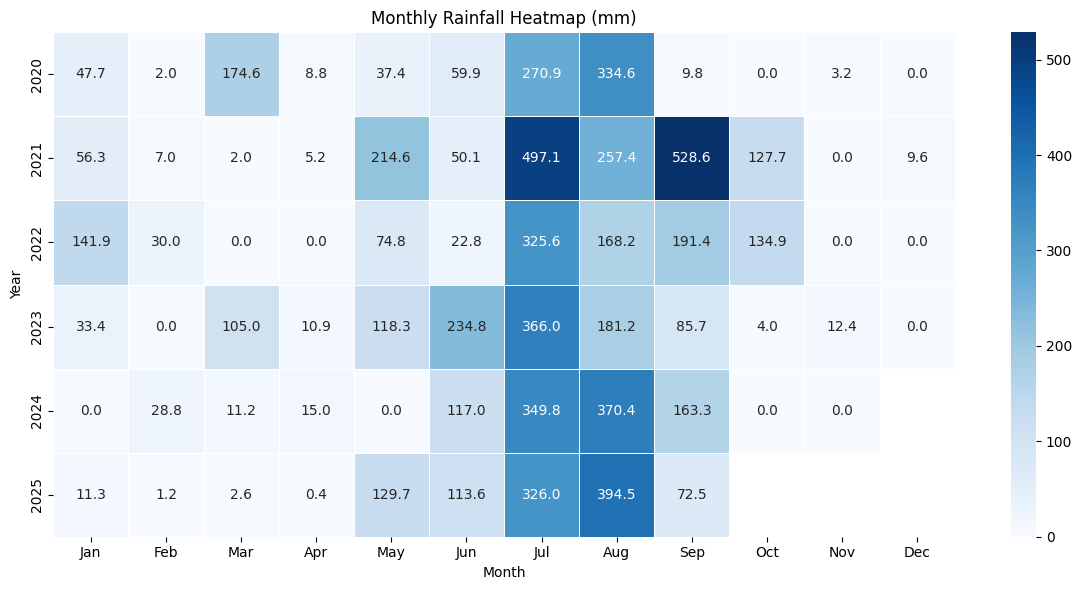

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot table: rows = years, columns = months
pivot = df_long_clean.pivot(index="Year", columns="Month", values="Rainfall_mm")

# Optional: Ensure months are in the correct order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot = pivot[month_order]

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="Blues", annot=True, fmt=".1f", linewidths=0.5)

plt.title("Monthly Rainfall Heatmap (mm)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [58]:
df_long[df_long["Flood_Prone"]].groupby("Month").size().sort_values(ascending=False)

Month
Aug    1
Jul    1
Sep    1
dtype: int64

In [60]:
import pandas as pd

# Define correct month order
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

# Add numeric month column
df_long_clean["Month_Num"] = df_long_clean["Month"].map(month_map)
df_long_clean = df_long_clean.sort_values(by=["Year", "Month_Num"]).reset_index(drop=True)
df_long_clean["Rolling_3_Months"] = df_long_clean["Rainfall_mm"].rolling(window=3).sum()
df_long_clean["Rolling_3_Months"] = df_long_clean["Rolling_3_Months"].round(1)
print(df_long_clean[["Year", "Month", "Rainfall_mm", "Rolling_3_Months"]].tail(12))

    Year  Month  Rainfall_mm  Rolling_3_Months
66  2025    Feb          1.2            1117.7
67  2025    Mar          2.6              15.1
68  2025    Apr          0.4               4.2
69  2025    May        129.7             132.7
70  2025    Jun        113.6             243.7
71  2025    Jul        326.0             569.3
72  2025    Aug        394.5             834.1
73  2025    Sep         72.5             793.0
74  2025    Oct          NaN               NaN
75  2025    Nov          NaN               NaN
76  2025    Dec          NaN               NaN
77  2025  Total       1051.8               NaN


In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Encode month
valid_months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Filter the DataFrame to keep only valid months
df1 = df_long_clean[df_long_clean["Month"].isin(valid_months)].copy()

# Now safely encode the month number
df1["Month_Num"] = pd.to_datetime(df1["Month"], format="%b").dt.month

X = df1[["Rainfall_mm", "Rolling_3_Months", "Month_Num"]].dropna()
y = df_long.loc[X.index, "Flood_Prone"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)
print("Model Accuracy:", model.score(X_test, y_test))


Model Accuracy: 1.0


#### Model is not very accurate due to insufficent training data.